# **Encoding and Standardizing**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving loan_processed.csv to loan_processed (2).csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay, precision_recall_fscore_support, precision_score, recall_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("loan_processed.csv")

In [ ]:
df.head()

,Age,Annual Income,Home ownership,Employment length,Loan intent,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Loan status
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,59,Y,3,1
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,1,N,2,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,57,N,3,1
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,53,N,2,1
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,55,Y,4,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    32574 non-null  int64  
 1   Annual Income          32574 non-null  int64  
 2   Home ownership         32574 non-null  object 
 3   Employment length      32574 non-null  float64
 4   Loan intent            32574 non-null  object 
 5   Loan grade             32574 non-null  object 
 6   Loan amount            32574 non-null  int64  
 7   Interest rate          32574 non-null  float64
 8   Percent income         32574 non-null  int64  
 9   Historical default     32574 non-null  object 
 10  Credit history length  32574 non-null  int64  
 11  Loan status            32574 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.0+ MB


We will standardize the numerical variables to reduce variance and quantify the categorical variables

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1:]

In [ ]:
X.head()

,Age,Annual Income,Home ownership,Employment length,Loan intent,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,1,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,55,Y,4


In [ ]:
y.head()

,Loan status
0,1
1,0
2,1
3,1
4,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = [
    "Age",
    "Annual Income",
    "Employment length",
    "Loan amount",
    "Interest rate",
    "Percent income",
    "Credit history length"
]
categorical_cols=["Home ownership","Loan intent","Loan grade","Historical default"]


In [ ]:
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [ ]:
X.head()

,Age,Annual Income,Home ownership,Employment length,Loan intent,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length
0,-0.923692,-0.131009,RENT,28.925834,PERSONAL,D,4.019449,1.625815,3.953434,Y,-0.691885
1,-1.085338,-1.071333,OWN,0.056751,EDUCATION,B,-1.358629,0.042315,-1.287732,N,-0.938744
2,-0.438753,-1.071333,MORTGAGE,-0.921862,MEDICAL,C,-0.646825,0.603679,3.772704,N,-0.691885
3,-0.762045,-0.007282,RENT,-0.187902,MEDICAL,C,4.019449,1.369470,3.411245,N,-0.938744
4,-0.600399,-0.218569,RENT,0.790711,MEDICAL,C,4.019449,1.057962,3.591975,Y,-0.445027


In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [ ]:
ohc = OneHotEncoder(sparse_output=False, drop="first")

encoded = ohc.fit_transform(
    X[["Home ownership", "Loan intent"]]
)

In [ ]:
cols = ohc.get_feature_names_out(["Home ownership", "Loan intent"])
encoded_df = pd.DataFrame(
    encoded,
    columns=cols,
    index=X.index
)

In [ ]:
encoded_df.head()

,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
X = X.drop(columns=["Home ownership", "Loan intent"])

X = pd.concat([X, encoded_df], axis=1)

In [ ]:
X.head()

,Age,Annual Income,Employment length,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
0,-0.923692,-0.131009,28.925834,D,4.019449,1.625815,3.953434,Y,-0.691885,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.085338,-1.071333,0.056751,B,-1.358629,0.042315,-1.287732,N,-0.938744,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.438753,-1.071333,-0.921862,C,-0.646825,0.603679,3.772704,N,-0.691885,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.762045,-0.007282,-0.187902,C,4.019449,1.369470,3.411245,N,-0.938744,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.600399,-0.218569,0.790711,C,4.019449,1.057962,3.591975,Y,-0.445027,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
lb=LabelEncoder()

In [ ]:
X['Historical default']=lb.fit_transform(X['Historical default'])

In [ ]:
X.head()

,Age,Annual Income,Employment length,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
0,-0.923692,-0.131009,28.925834,D,4.019449,1.625815,3.953434,1,-0.691885,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.085338,-1.071333,0.056751,B,-1.358629,0.042315,-1.287732,0,-0.938744,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.438753,-1.071333,-0.921862,C,-0.646825,0.603679,3.772704,0,-0.691885,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.762045,-0.007282,-0.187902,C,4.019449,1.369470,3.411245,0,-0.938744,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.600399,-0.218569,0.790711,C,4.019449,1.057962,3.591975,1,-0.445027,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
oe = OrdinalEncoder(categories=[["A","B","C","D","E","F","G"]])

X["Loan grade"] = oe.fit_transform(X[["Loan grade"]])

In [ ]:
X.head()

,Age,Annual Income,Employment length,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
0,-0.923692,-0.131009,28.925834,3.0,4.019449,1.625815,3.953434,1,-0.691885,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.085338,-1.071333,0.056751,1.0,-1.358629,0.042315,-1.287732,0,-0.938744,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.438753,-1.071333,-0.921862,2.0,-0.646825,0.603679,3.772704,0,-0.691885,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.762045,-0.007282,-0.187902,2.0,4.019449,1.369470,3.411245,0,-0.938744,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.600399,-0.218569,0.790711,2.0,4.019449,1.057962,3.591975,1,-0.445027,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# **Evaluating Imbalances**

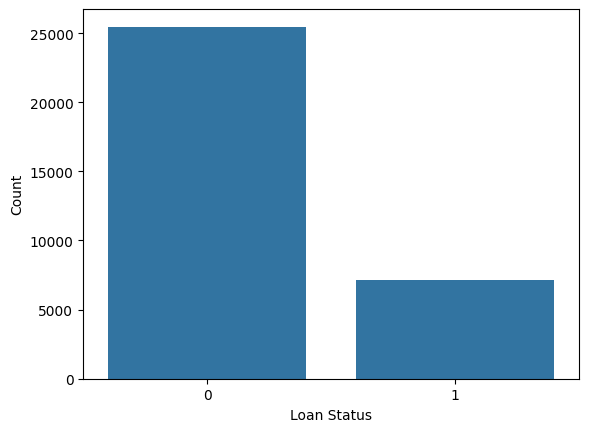

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

y_count = y.value_counts().reset_index()
y_count.columns = ["Loan Status", "Count"]

sns.barplot(
    data=y_count,
    x="Loan Status",
    y="Count"
)

plt.show()

In [ ]:
y.value_counts(normalize=True) * 100

,proportion
Loan status,
0,78.178916
1,21.821084


Although the dataset is imbalanced, the minority class still accounts for over 20% of the observations. Therefore, the class imbalance is considered moderate rather than severe

In [ ]:
rs=123
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = rs)


In [ ]:
print(f"Training dataset shape, X_train: {X_train.shape}, y_train: {y_train.shape}")

Training dataset shape, X_train: (26059, 17), y_train: (26059, 1)


In [ ]:
print(f"Testing dataset shape, X_test: {X_test.shape}, y_test: {y_test.shape}")

Testing dataset shape, X_test: (6515, 17), y_test: (6515, 1)


# **Model Evaluation**

# Logistic Regression

In [ ]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

In [ ]:
# L2 penalty to shrink coefficients without removing any features from the model
penalty= 'l2'
# Our classification problem is multinomial
multi_class = 'multinomial'
# Use lbfgs for L2 penalty and multinomial classes
solver = 'lbfgs'
# Max iteration = 1000
max_iter = 1000

In [ ]:
l2_model = LogisticRegression(random_state=rs, penalty=penalty, multi_class=multi_class, solver=solver, max_iter=max_iter)

In [ ]:
l2_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=123)

In [ ]:
y_pred2=l2_model.predict(X_test)

In [ ]:
log2=evaluate_metrics(y_test, y_pred2)

In [ ]:
# L1 penalty to shrink coefficients without removing any features from the model
penalty= 'l1'
# Our classification problem is multinomial
multi_class = 'multinomial'
# Use saga for L1 penalty and multinomial classes
solver = 'saga'
# Max iteration = 1000
max_iter = 1000

In [ ]:
l1_model=LogisticRegression(penalty=penalty, multi_class=multi_class, solver="saga", max_iter=1000, random_state=rs)

In [ ]:
l1_model.fit(X_train, y_train)
y_pred1=l1_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
log1=evaluate_metrics(y_test, y_pred1)

In [ ]:
log1 = pd.DataFrame([evaluate_metrics(y_test, y_pred1)],
                    index=["L1"])

log2 = pd.DataFrame([evaluate_metrics(y_test, y_pred2)],
                    index=["L2"])

results = pd.concat([log1, log2])

In [ ]:
results

,accuracy,recall,precision,f1score
L1,0.854490,"[0.9520911054388376, 0.5049226441631505]","[0.8732216819737079, 0.7463617463617463]","[0.9109524704114221, 0.6023489932885906]"
L2,0.854336,"[0.9518947575103083, 0.5049226441631505]","[0.8731988472622478, 0.7455867082035307]","[0.9108501643964303, 0.6020964360587002]"


Although the evaluation metrics of the two logistic regression models were relatively the same, the recall metric and f1 score were not good.

In [ ]:
cf1=confusion_matrix(y_test, y_pred1)
cf2=confusion_matrix(y_test, y_pred1)

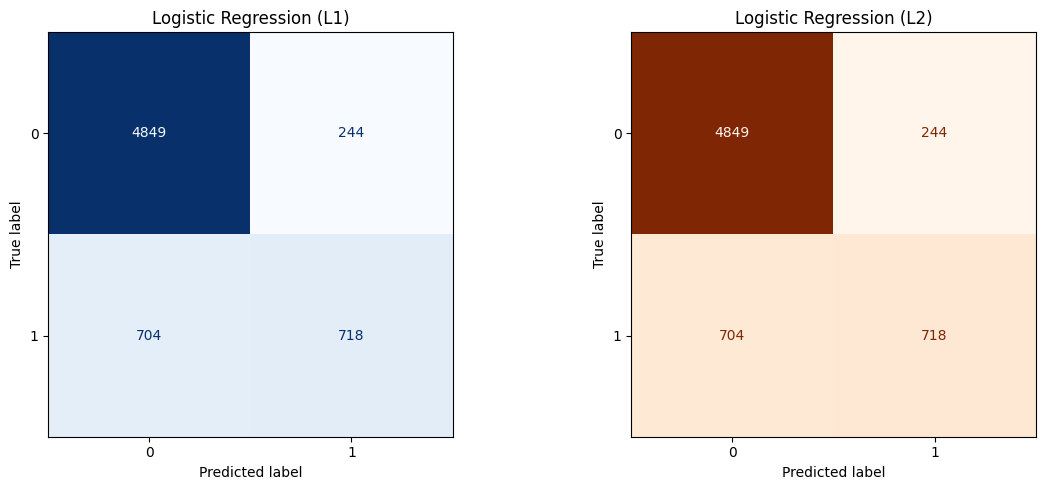

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# L1
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cf1,
    display_labels=l1_model.classes_
)
disp1.plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Logistic Regression (L1)")

# L2
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cf2,
    display_labels=l2_model.classes_
)
disp2.plot(ax=ax[1], cmap="Oranges", colorbar=False)
ax[1].set_title("Logistic Regression (L2)")

plt.tight_layout()
plt.show()

# K-Nearest Neighboor

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  f1_score

In [ ]:
max_k=50

In [ ]:
f1_scores=list()
for k in range(max_k):
   knn=KNeighborsClassifier(n_neighbors=max_k, weights="distance")
   knn.fit(X_train, y_train)
   y_knn=knn.predict(X_test)
   f1_scores.append((k, round(f1_score(y_test, y_knn), 4)))


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

In [ ]:
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])

In [ ]:
f1_results.set_index("K", inplace=True)

<Axes: xlabel='K'>

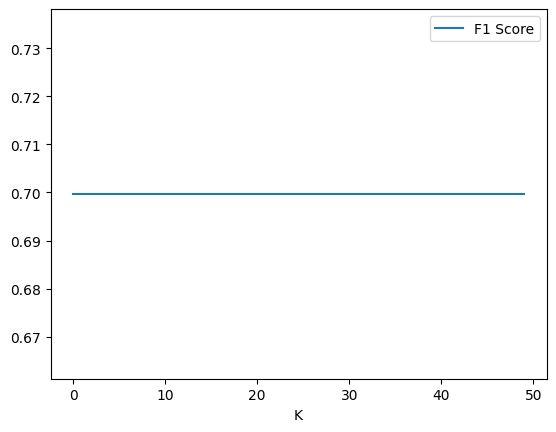

In [ ]:
f1_results.plot()

As clearly seen from the graph, the F1 Score does not change when the number of k changes. However, we did see an improvement from the last model when the F1 Score increases.

# Support vector machine

In [ ]:
from sklearn.svm import LinearSVC

LSVC = LinearSVC()
LSVC.fit(X_train, y_train)
y_svc1=LSVC.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
evaluate_metrics(y_test, y_svc1)

{'accuracy': 0.8534151957022257,
 'recall': array([0.96014137, 0.47116737]),
 'precision': array([0.86671393, 0.7674685 ]),
 'f1score': array([0.91103866, 0.583878  ])}

In [ ]:
from sklearn.svm import SVC
svc=SVC(kernel='rbf')

In [ ]:
svc.fit(X_train, y_train)
y_svc2=svc.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
evaluate_metrics(y_test,y_svc2)

{'accuracy': 0.9131235610130468,
 'recall': array([0.98802278, 0.64486639]),
 'precision': array([0.90879538, 0.93762781]),
 'f1score': array([0.94675447, 0.76416667])}

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='log_loss', random_state=123)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

criterion = ["gini", "entropy", "log_loss"]

results = []

for i in criterion:
    dt = DecisionTreeClassifier(
        criterion=i,
        random_state=123
    )

    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    metrics = evaluate_metrics(y_test, y_pred)
    metrics["Criterion"] = i

    results.append(metrics)

results = pd.DataFrame(results)
results

,accuracy,recall,precision,f1score,Criterion
0,0.885955,"[0.9143923031612017, 0.7841068917018285]","[0.9381547139403706, 0.7188910380399742]","[0.9261211096748533, 0.7500840901446351]",gini
1,0.895472,"[0.9285293540153151, 0.7770745428973277]","[0.9371779627427665, 0.7522123893805309]","[0.9328336127823257, 0.7644413697682463]",entropy
2,0.895472,"[0.9285293540153151, 0.7770745428973277]","[0.9371779627427665, 0.7522123893805309]","[0.9328336127823257, 0.7644413697682463]",log_loss


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)

y_rf=rf.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
evaluate_metrics(y_test, y_rf)

{'accuracy': 0.9370683039140445,
 'recall': array([0.99253878, 0.73839662]),
 'precision': array([0.93145384, 0.96507353]),
 'f1score': array([0.96102662, 0.83665339])}

# Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier
Bag=BaggingClassifier()

In [ ]:
Bag.fit(X_train, y_train)
y_bag=Bag.predict(X_test)
evaluate_metrics(y_test,y_bag)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'accuracy': 0.9320030698388334,
 'recall': array([0.98704104, 0.73488045]),
 'precision': array([0.93023686, 0.94059406]),
 'f1score': array([0.95779747, 0.82510857])}

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
Boosting=GradientBoostingClassifier()
Boosting.fit(X_train, y_train)
y_boost=Boosting.predict(X_test)
evaluate_metrics(y_test,y_boost)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'accuracy': 0.9241749808135072,
 'recall': array([0.98723738, 0.69831224]),
 'precision': array([0.92138538, 0.93856333]),
 'f1score': array([0.95317536, 0.80080645])}

From the results above, we choose Bagging and Random Forest as the two main classification techniques. We are going to optimize these models.

# **Hyperparameter Tuning and Feature Importance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the random forest estimator
# Note that the number of trees is not setup here
RF = RandomForestClassifier(oob_score=True,
                            random_state=42,
                            warm_start=True,
                            n_jobs=-1)

oob_list = list()

# Iterate through all of the possibilities for
# number of trees
for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400]:

    # Use this to set the number of trees
    RF.set_params(n_estimators=n_trees)

    # Fit the model
    RF.fit(X_train, y_train)

    # Get the oob error
    oob_error = 1 - RF.oob_score_

    # Store it
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob_error': oob_error}))

rf_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

rf_oob_df

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/skle

,oob_error
n_trees,
15.0,0.082774
20.0,0.077133
30.0,0.072566
40.0,0.071146
50.0,0.070302
100.0,0.067846
150.0,0.067270
200.0,0.066848
300.0,0.066618


[Text(0, 0.5, 'out-of-bag error')]

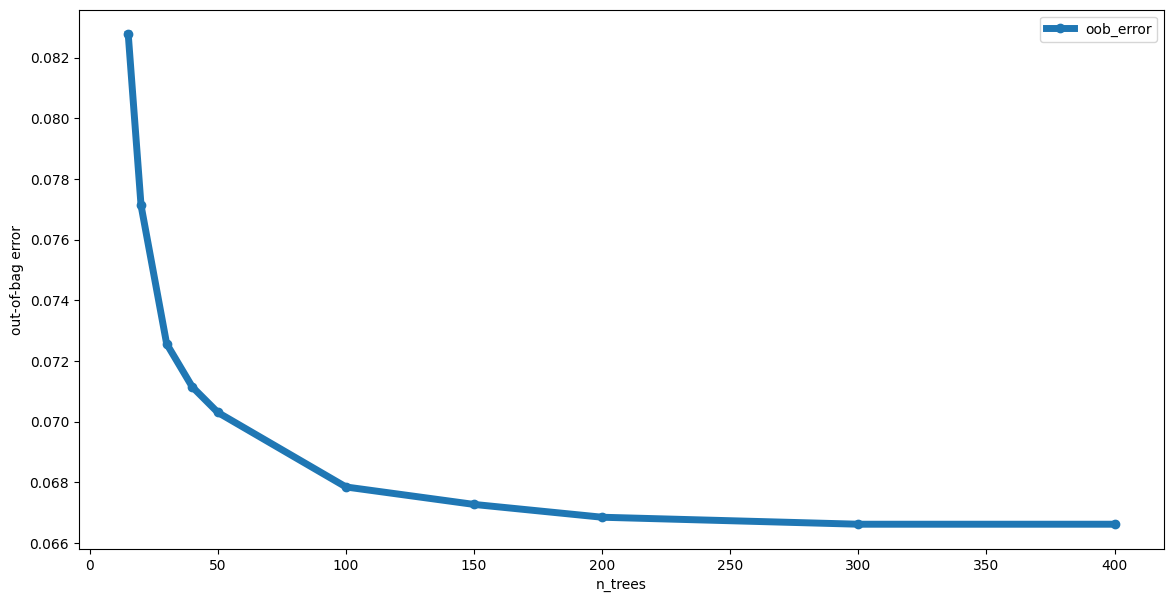

In [ ]:
ax = rf_oob_df.plot(marker='o', figsize=(14, 7), linewidth=5)
ax.set(ylabel='out-of-bag error')

It seems that the model's performance stabilizes at around 300 trees. Therefore, we selected 200 as the number of trees for the final Random Forest model. We did not use GridSearchCV or RandomizedSearchCV for hyperparameter tuning due to technical limitations, mainly the computer incapacity to run each parameter consecutively.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=123
)

The Random Forest classifier was configured with 300 decision trees, as the model performance stabilized around this value while avoiding unnecessary computational cost. The maximum tree depth was limited to 15 to control model complexity and reduce overfitting. The parameters min_samples_split = 10 and min_samples_leaf = 5 were selected to prevent overly specific tree structures by requiring a sufficient number of samples for node splitting and leaf formation. Furthermore, max_features = "sqrt" was adopted to increase the diversity among individual trees, thereby improving the model's generalization capability. Finally, a fixed random_state was used to ensure reproducibility of the experimental results.

In [ ]:
RF.fit(X_train, y_train)
y_rf=RF.predict(X_test)
y_prob_rf=RF.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
evaluate_metrics(y_test, y_rf)

{'accuracy': 0.9333844973138911,
 'recall': array([0.99332417, 0.71870605]),
 'precision': array([0.92672651, 0.96780303]),
 'f1score': array([0.95887036, 0.82485876])}

In [ ]:
def score_df(y_test, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }

score_df(y_test, y_rf, y_prob_rf)

{'accuracy': 0.9333844973138911,
 'precision': 0.9678030303030303,
 'recall': 0.7187060478199718,
 'f1': 0.8248587570621468,
 'auc': np.float64(0.9354564868412367)}

Although precision and recall are not equal, the F1-score achieves a reasonable balance between the two metrics. This suggests that the model provides a credible overall classification performance.

In [ ]:
from sklearn.metrics import f1_score

train_f1 = f1_score(y_train, RF.predict(X_train))
test_f1 = f1_score(y_test, RF.predict(X_test))

print(train_f1)
print(test_f1)


0.8393037846589759
0.8248587570621468


The model shows there is no major difference between the training set and testing set, proving the model is not overfitting.

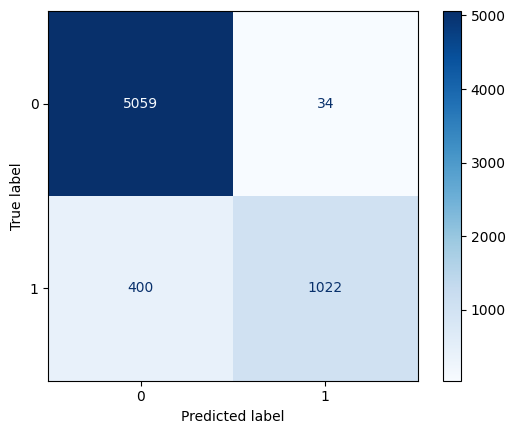

In [ ]:
cf=confusion_matrix(y_test, y_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=cf)
disp.plot(cmap="Blues")

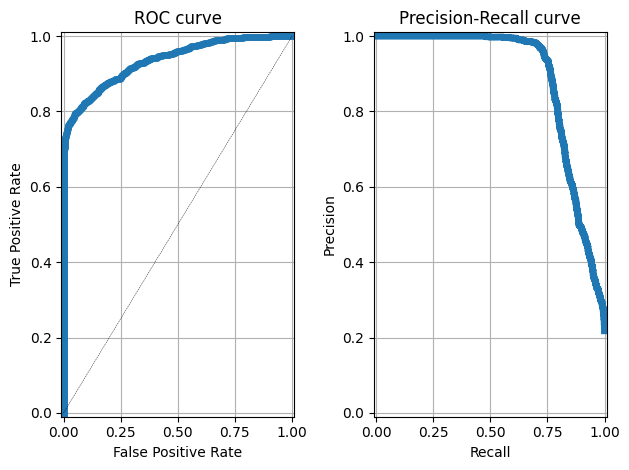

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve
fig, ax = plt.subplots(ncols=2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
ax[0].plot(fpr, tpr, linewidth=5)
ax[0].plot([0, 1], [0, 1], ls='--', color='black', lw=.3)
ax[0].set(xlabel='False Positive Rate',
       ylabel='True Positive Rate',
       xlim=[-.01, 1.01], ylim=[-.01, 1.01],
       title='ROC curve')
ax[0].grid(True)

precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
ax[1].plot(recall, precision, linewidth=5)
ax[1].set(xlabel='Recall', ylabel='Precision',
       xlim=[-.01, 1.01], ylim=[-.01, 1.01],
       title='Precision-Recall curve')
ax[1].grid(True)

plt.tight_layout()

* The ROC curve indicates that the model effectively distinguishes between default and non-default clients across a wide range of classification thresholds, demonstrating excellent discriminative performance.
* From the ROC curve, a point with a True Positive Rate (TPR) of approximately 0.80 corresponds to a False Positive Rate (FPR) of around 0.10. This means that the model correctly identifies about 80% of clients who actually default, while incorrectly classifying only 10% of clients who actually do not default as defaulters.
* he Precision-Recall curve illustrates the trade-off between precision and recall. When precision is maintained close to 1.0, the corresponding recall is only around 0.6. A more balanced operating point can be achieved where both precision and recall are approximately 0.8. Conversely, increasing recall to nearly 1.0 causes precision to drop to around 0.2, indicating a substantial increase in false positive predictions.


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    RF,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=123
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(importance)

Loan grade                     0.242338
Percent income                 0.204180
Home ownership_RENT            0.154169
Annual Income                  0.114317
Loan intent_HOMEIMPROVEMENT    0.037142
Employment length              0.036780
Loan intent_EDUCATION          0.026328
Loan amount                    0.026022
Loan intent_PERSONAL           0.021233
Loan intent_VENTURE            0.020553
Loan intent_MEDICAL            0.010909
Home ownership_OWN             0.008882
Interest rate                  0.001776
Age                            0.001169
Historical default             0.000275
Home ownership_OTHER           0.000000
Credit history length         -0.002516
dtype: float64


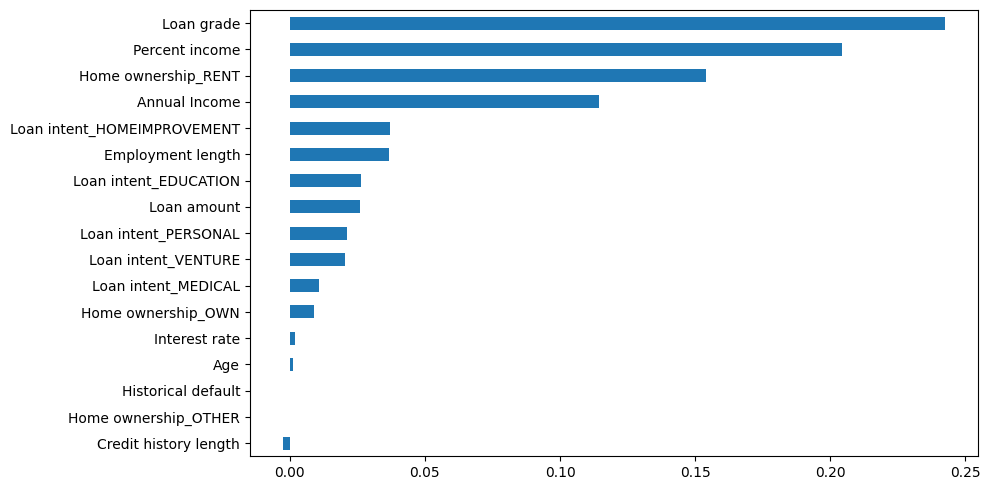

In [ ]:
importance.sort_values().plot(kind="barh", figsize=(10,5))

plt.tight_layout()
plt.show()

The graph shows that the **Loan grade** is the most importanct factor affecting the outcome, followed by the **percent income** and the **home ownership_rent**. Other factors also contribute to the chance of default, except the **historical default** and **home ownership_Other** having no contribution at all. We could try to exclude these two variables.

In [ ]:
drop_cols = ["Historical default", "Home ownership_OTHER"]

X_train_new = X_train.drop(columns=drop_cols)
X_test_new = X_test.drop(columns=drop_cols)

In [ ]:
RF.fit(X_train_new, y_train)
y_rf_new=RF.predict(X_test_new)
y_prob_rf_new=RF.predict_proba(X_test_new)[:,1]
score_df(y_test, y_rf_new, y_prob_rf_new)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'accuracy': 0.9343054489639294,
 'precision': 0.9697542533081286,
 'recall': 0.7215189873417721,
 'f1': 0.8274193548387097,
 'auc': np.float64(0.9353436765334953)}

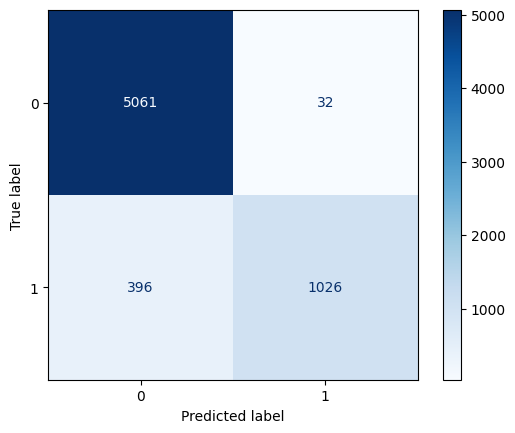

In [ ]:
cf=confusion_matrix(y_test, y_rf_new)
disp=ConfusionMatrixDisplay(confusion_matrix=cf)
disp.plot(cmap="Blues")

The removal of the two least important features resulted in a slight improvement in model performance. This suggests that these features contributed little to the predictive capability of the model and may have introduced redundant or noisy information.

In [ ]:

Bag = BaggingClassifier(
    oob_score=True,
    random_state=42,
    warm_start=False,
    n_jobs=-1
)

oob_list = []

for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400]:

    Bag.set_params(n_estimators=n_trees)

    Bag.fit(X_train, y_train)

    oob_error = 1 - Bag.oob_score_

    oob_list.append(
        pd.Series({
            "n_trees": n_trees,
            "oob_error": oob_error
        })
    )

bag_oob_df = pd.concat(oob_list, axis=1).T.set_index("n_trees")

print(bag_oob_df)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/en

         oob_error
n_trees           
15.0      0.074485
20.0      0.072413
30.0      0.070110
40.0      0.069228
50.0      0.067539
100.0     0.066695
150.0     0.066733
200.0     0.066311
300.0     0.065160
400.0     0.064968


The OOB error decreased as the number of trees increased and became nearly stable after approximately 300 trees. Although using 400 trees produced a slightly lower OOB error, the improvement was negligible. Therefore, 300 trees were selected as a trade-off between predictive performance and computational efficiency

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

base_tree = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=123
)

bag = BaggingClassifier(
    estimator=base_tree,
    n_estimators=300,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    oob_score=True,
    random_state=123,
    n_jobs=-1
)

In [ ]:
bag.fit(X_train,y_train)
y_bag=bag.predict(X_test)
y_prob_bag=bag.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
evaluate_metrics(y_test, y_bag)

{'accuracy': 0.9344589409056024,
 'recall': array([0.99469861, 0.71870605]),
 'precision': array([0.92682034, 0.9742612 ]),
 'f1score': array([0.95956056, 0.82719547])}

In [ ]:
score_df(y_test, y_bag, y_prob_bag)

{'accuracy': 0.9344589409056024,
 'precision': 0.9742612011439467,
 'recall': 0.7187060478199718,
 'f1': 0.8271954674220963,
 'auc': np.float64(0.936255824505271)}

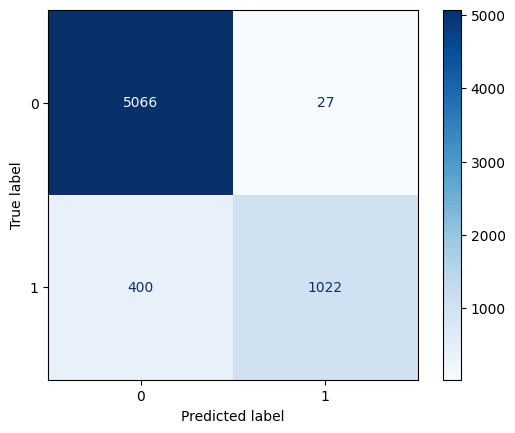

In [ ]:
cf=confusion_matrix(y_test, y_bag)
disp=ConfusionMatrixDisplay(confusion_matrix=cf)
disp.plot(cmap="Blues")

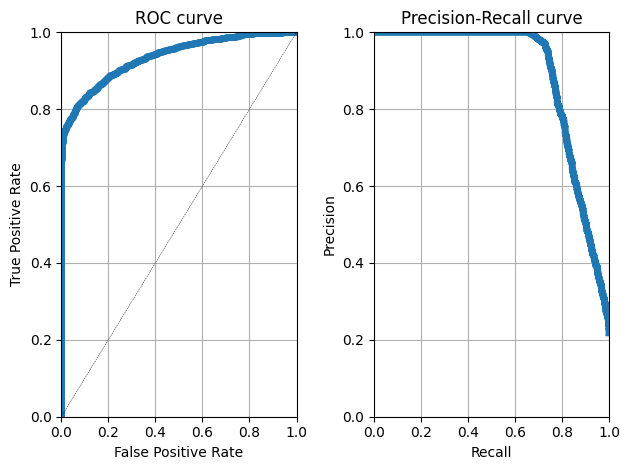

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve
fig, ax = plt.subplots(ncols=2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_bag)
ax[0].plot(fpr, tpr, linewidth=5)
ax[0].plot([0, 1], [0, 1], ls='--', color='black', lw=.3)
ax[0].set(xlabel='False Positive Rate',
       ylabel='True Positive Rate',
       xlim=[-.0, 1.0], ylim=[-.0, 1.0],
       title='ROC curve')
ax[0].grid(True)

precision, recall, _ = precision_recall_curve(y_test, y_prob_bag)
ax[1].plot(recall, precision, linewidth=5)
ax[1].set(xlabel='Recall', ylabel='Precision',
       xlim=[-.0, 1.0], ylim=[-.0, 1.0],
       title='Precision-Recall curve')
ax[1].grid(True)

plt.tight_layout()

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    bag,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=123
)

importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(importance)

Loan grade                     0.246393
Home ownership_RENT            0.161830
Percent income                 0.147244
Annual Income                  0.142105
Loan amount                    0.081946
Loan intent_HOMEIMPROVEMENT    0.043702
Employment length              0.042981
Loan intent_EDUCATION          0.026249
Loan intent_PERSONAL           0.021703
Loan intent_VENTURE            0.021142
Loan intent_MEDICAL            0.012914
Age                            0.010737
Home ownership_OWN             0.009600
Interest rate                  0.002892
Credit history length          0.000105
Home ownership_OTHER          -0.000047
Historical default            -0.000664
dtype: float64


The Bagging model also shows that the top three major contributors are the **Loan grade**, **Home ownership_RENT**, **Percent income**.

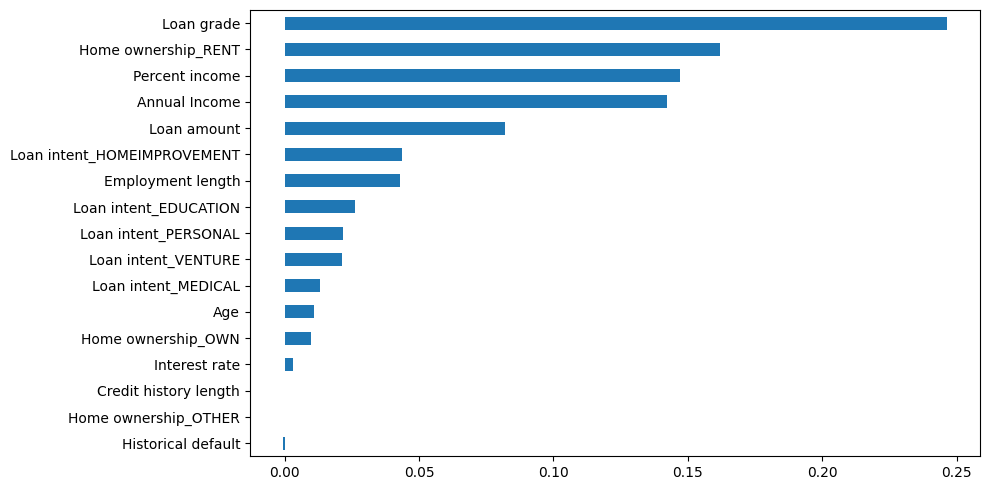

In [ ]:
importance.sort_values().plot(kind="barh", figsize=(10,5))

plt.tight_layout()
plt.show()

We could also try to exclude the two variables **Historical default** and **Home ownership_OTHER**.

In [ ]:
drop_cols = ["Historical default", "Home ownership_OTHER"]

X_train_new = X_train.drop(columns=drop_cols)
X_test_new = X_test.drop(columns=drop_cols)

In [ ]:
bag.fit(X_train_new, y_train)
y_bag_new=bag.predict(X_test_new)
y_prob_bag_new=bag.predict_proba(X_test_new)[:,1]
score_df(y_test,y_bag_new, y_prob_bag_new)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'accuracy': 0.9344589409056024,
 'precision': 0.9760765550239234,
 'recall': 0.7172995780590717,
 'f1': 0.8269152817186867,
 'auc': np.float64(0.9356513159039337)}

Obviously, reducing the number of features does not result in better performance of the model. Therefore, we decide to keep these features.

# **Error Analysis**

In [323]:
result = X_test.copy()
result["Actual"] = y_test.values
result["Predicted"] = y_rf_new
result["Probability"] = y_prob_rf_new
wrong = result[result["Actual"] != result["Predicted"]]
wrong_index=wrong.index
wrong.head(10)

,Age,Annual Income,Employment length,Loan grade,Loan amount,Interest rate,Percent income,Historical default,Credit history length,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE,Actual,Predicted,Probability
20767,0.046185,-0.587847,-1.166515,0.0,-0.725914,-0.684538,-0.112988,0,0.789268,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.432739
30237,1.985939,-0.416532,-1.166515,0.0,-0.567735,-0.006358,-0.112988,0,1.529845,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,0,0.045439
20189,0.369478,-0.606881,0.301404,2.0,-0.884093,0.804861,-0.293718,0,-0.198168,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.221393
24746,0.369478,0.059341,-0.432556,2.0,-0.172288,-0.006358,-0.293718,0,-0.198168,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0.105145
6455,-0.600399,-0.416532,-0.187902,0.0,-1.168815,-0.684538,-0.926273,0,-0.445027,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0.106256
6364,-0.438753,-0.683021,1.035364,3.0,-0.567735,1.210471,-1.197367,1,-0.445027,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,0.322637
11838,-0.277107,0.087893,1.524670,0.0,0.776784,-1.142065,0.519567,0,-0.691885,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0.052960
17852,0.531124,1.601169,-0.187902,3.0,4.019449,2.349423,0.700296,0,0.048691,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1,0,0.416158
15721,-0.277107,0.493337,0.546057,2.0,0.927054,-0.032317,-0.112988,1,-0.691885,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0,0.063669
13482,-0.438753,0.268801,0.790711,0.0,-0.567735,-0.976577,-0.745543,0,-0.938744,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0,0.022874


In [321]:
correct = result[result["Actual"] == result["Predicted"]]
correct_index=correct.index

In [309]:
result_1=wrong[["Actual","Predicted","Probability"]]
result_1

,Actual,Predicted,Probability
20767,1,0,0.432739
30237,1,0,0.045439
20189,1,0,0.221393
24746,1,0,0.105145
6455,1,0,0.106256
...,...,...,...
23252,1,0,0.158297
5838,0,1,0.553906
4825,1,0,0.368811
24520,1,0,0.186759


In [324]:
result_2=correct[["Actual","Predicted","Probability"]]
result_2

,Actual,Predicted,Probability
5288,0,0,0.004555
10305,0,0,0.085296
25449,0,0,0.052526
7256,0,0,0.105809
4599,0,0,0.107563
...,...,...,...
7491,0,0,0.036739
19281,0,0,0.058171
1745,1,1,0.509278
7819,0,0,0.172198


In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    32574 non-null  int64  
 1   Annual Income          32574 non-null  int64  
 2   Home ownership         32574 non-null  object 
 3   Employment length      32574 non-null  float64
 4   Loan intent            32574 non-null  object 
 5   Loan grade             32574 non-null  object 
 6   Loan amount            32574 non-null  int64  
 7   Interest rate          32574 non-null  float64
 8   Percent income         32574 non-null  int64  
 9   Historical default     32574 non-null  object 
 10  Credit history length  32574 non-null  int64  
 11  Loan status            32574 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.0+ MB


In [345]:
df.drop(df.columns[[2,4,5,9]], axis=1)

In [346]:
df_11 = df.drop(df.columns[[2,4,5,9]], axis=1).copy()
df_2=X.iloc[:,[3,7,9,10,11,12,13,14,15,16]]

In [347]:
df_12=pd.concat([df_11, df_2], axis=1)
df_12.head()

,Age,Annual Income,Employment length,Loan amount,Interest rate,Percent income,Credit history length,Loan status,Loan grade,Historical default,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
0,22,59000,123.0,35000,16.02,59,3,1,3.0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21,9600,5.0,1000,11.14,1,2,0,1.0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25,9600,1.0,5500,12.87,57,3,1,2.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,23,65500,4.0,35000,15.23,53,2,1,2.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,24,54400,8.0,35000,14.27,55,4,1,2.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [348]:
df_12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          32574 non-null  int64  
 1   Annual Income                32574 non-null  int64  
 2   Employment length            32574 non-null  float64
 3   Loan amount                  32574 non-null  int64  
 4   Interest rate                32574 non-null  float64
 5   Percent income               32574 non-null  int64  
 6   Credit history length        32574 non-null  int64  
 7   Loan status                  32574 non-null  int64  
 8   Loan grade                   32574 non-null  float64
 9   Historical default           32574 non-null  int64  
 10  Home ownership_OTHER         32574 non-null  float64
 11  Home ownership_OWN           32574 non-null  float64
 12  Home ownership_RENT          32574 non-null  float64
 13  Loan intent_EDUC

In [349]:
df_1=df_12.loc[wrong_index]
df_1

,Age,Annual Income,Employment length,Loan amount,Interest rate,Percent income,Credit history length,Loan status,Loan grade,Historical default,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
20767,28,35000,0.0,5000,8.90,14,9,1,0.0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
30237,40,44000,0.0,6000,10.99,14,12,1,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
20189,30,34000,6.0,4000,13.49,12,5,1,2.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
24746,30,69000,3.0,8500,10.99,12,5,1,2.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6455,24,44000,4.0,2200,8.90,5,4,1,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23252,31,24996,0.0,5000,12.99,2,8,1,2.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5838,26,34000,3.0,5500,16.89,16,2,0,3.0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4825,25,36000,2.0,13750,13.22,38,4,1,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24520,29,54000,5.0,10000,13.49,19,9,1,2.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [350]:
df_2=df_12.loc[correct_index]
df_2

,Age,Annual Income,Employment length,Loan amount,Interest rate,Percent income,Credit history length,Loan status,Loan grade,Historical default,Home ownership_OTHER,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE
5288,21,45000,2.0,6000,10.99,13,2,0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10305,25,66500,9.0,5000,9.63,8,3,0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25449,33,72000,3.0,12000,11.99,17,5,0,1.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7256,22,52000,5.0,3000,14.35,6,2,0,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4599,25,116000,5.0,10000,14.26,9,4,0,2.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7491,23,55000,1.0,6800,11.49,12,2,0,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
19281,27,40000,4.0,2500,6.99,6,5,0,0.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1745,24,10000,2.0,2000,10.25,2,2,1,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7819,22,55000,5.0,11100,16.77,2,2,0,3.0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [351]:
merge=pd.concat([df_1, result_1], axis=1)
merge

,Age,Annual Income,Employment length,Loan amount,Interest rate,Percent income,Credit history length,Loan status,Loan grade,Historical default,...,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE,Actual,Predicted,Probability
20767,28,35000,0.0,5000,8.90,14,9,1,0.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.432739
30237,40,44000,0.0,6000,10.99,14,12,1,0.0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,0,0.045439
20189,30,34000,6.0,4000,13.49,12,5,1,2.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.221393
24746,30,69000,3.0,8500,10.99,12,5,1,2.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0.105145
6455,24,44000,4.0,2200,8.90,5,4,1,0.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0.106256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23252,31,24996,0.0,5000,12.99,2,8,1,2.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.158297
5838,26,34000,3.0,5500,16.89,16,2,0,3.0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1,0.553906
4825,25,36000,2.0,13750,13.22,38,4,1,2.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.368811
24520,29,54000,5.0,10000,13.49,19,9,1,2.0,1,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0,0.186759


In [352]:
merge_2=pd.concat([df_2, result_2], axis=1)
merge_2

,Age,Annual Income,Employment length,Loan amount,Interest rate,Percent income,Credit history length,Loan status,Loan grade,Historical default,...,Home ownership_OWN,Home ownership_RENT,Loan intent_EDUCATION,Loan intent_HOMEIMPROVEMENT,Loan intent_MEDICAL,Loan intent_PERSONAL,Loan intent_VENTURE,Actual,Predicted,Probability
5288,21,45000,2.0,6000,10.99,13,2,0,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.004555
10305,25,66500,9.0,5000,9.63,8,3,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.085296
25449,33,72000,3.0,12000,11.99,17,5,0,1.0,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,0.052526
7256,22,52000,5.0,3000,14.35,6,2,0,2.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.105809
4599,25,116000,5.0,10000,14.26,9,4,0,2.0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0.107563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7491,23,55000,1.0,6800,11.49,12,2,0,1.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,0,0.036739
19281,27,40000,4.0,2500,6.99,6,5,0,0.0,0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0,0,0.058171
1745,24,10000,2.0,2000,10.25,2,2,1,1.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,1,0.509278
7819,22,55000,5.0,11100,16.77,2,2,0,3.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,0.172198


In [353]:
#Wrong prediction
fn = merge[
    (merge["Actual"] == 1) &
    (merge["Predicted"] == 0)
]

fp = merge[
    (merge["Actual"] == 0) &
    (merge["Predicted"] == 1)
]

#True prediction
tp = merge_2[
    (merge_2["Actual"] == 1) &
    (merge_2["Predicted"] == 1)
]

tn = merge_2[
    (merge_2["Actual"] == 0) &
    (merge_2["Predicted"] == 0)
]

In [354]:
FN=fn.iloc[:, :-3]
FP=fp.iloc[:, :-3]
TP=tp.iloc[:, :-3]
TN=tn.iloc[:, :-3]

In [355]:
comparison = pd.DataFrame({
    "TN": TN.mean(numeric_only=True),
    "FN": FN.mean(numeric_only=True),
    "TP": TP.mean(numeric_only=True),
    "FP": FP.mean(numeric_only=True)
})

comparison

,TN,FN,TP,FP
Age,27.936179,27.888889,27.419103,28.218750
Annual Income,71466.757163,59418.489899,46366.946394,36955.531250
Employment length,4.931239,4.810606,3.697856,6.281250
Loan amount,9237.097412,9151.136364,11592.884990,9207.812500
Interest rate,10.445451,11.760126,13.429493,16.060938
Percent income,13.161035,14.181818,25.613060,22.968750
Credit history length,5.900020,5.919192,5.656920,5.437500
Loan status,0.000000,1.000000,1.000000,0.000000
Loan grade,0.965224,1.467172,2.327485,3.218750
Historical default,0.140881,0.227273,0.324561,0.406250


Error analysis was conducted by comparing the characteristics of True Negative (TN), False Negative (FN), True Positive (TP), and False Positive (FP) instances. The results indicate that the Random Forest model successfully captured the major risk patterns associated with loan default; however, it still struggled to distinguish certain borrowers with similar characteristics.

Compared with the True Negative group, False Negative borrowers exhibited lower annual income (59,418 vs. 71,467), higher interest rates (11.76% vs. 10.45%), and a slightly higher loan-to-income ratio (14.18 vs. 13.16). However, only minor differences were observed in age, employment length, loan amount, and credit history length. This suggests that False Negative(**True default**) borrowers share many characteristics with correctly classified non-default borrowers, making them difficult for the model to identify.

Compared with the True Positive group, False Positive borrowers had lower annual income (36,956 vs. 46,367), higher interest rates (16.06% vs. 13.43%), and a substantially higher proportion of medical-purpose loans. These characteristics are generally associated with higher credit risk, leading the model to classify these borrowers as likely to default even though they ultimately repaid their loans successfully.

Overall, the error analysis indicates that **loan grade, Home ownership_RENT, annual income, interest rate, and loan-to-income ratio** are among the most influential factors affecting the model's predictions. Nevertheless, the overlap in borrower characteristics between the default and non-default classes results in both False Negative and False Positive predictions. These findings suggest that incorporating additional borrower information or developing more discriminative features may further improve the model's classification performance.